### Caso Práctico en R: Predicción de Bajo Peso al Nacer
Utilizaremos el conjunto de datos real birthwt del paquete MASS, el cual registra factores de riesgo asociados a 189 nacimientos en el Baystate Medical Center.
Objetivo: Modelar la probabilidad de que un neonato tenga bajo peso (low: 1=Sí, 0=No) basado en el peso materno previo (lwt) y el hábito de fumar (smoke)

Waiting for profiling to be done...
[1] "Razones de Momios (Odds Ratios):"
                  OR     2.5 %    97.5 %
(Intercept) 1.862644 0.4134732 9.5328864
lwt         0.986764 0.9742622 0.9979533
smokeFuma   1.967322 1.0417154 3.7335464
Varianza explicada aproximada: 4.402462 %

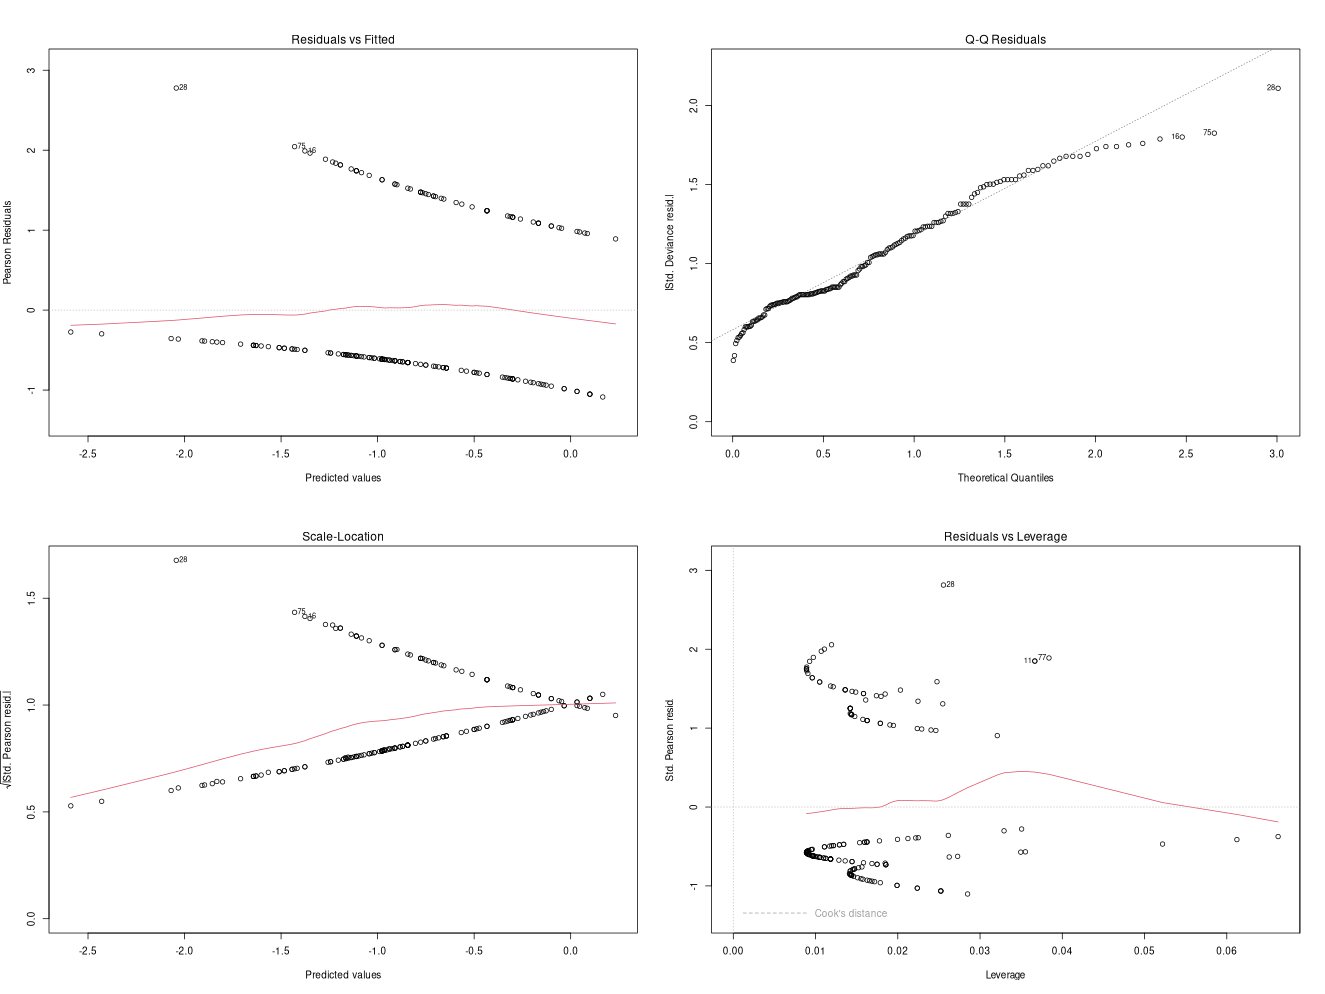

In [1]:
# --- Script: Regresión Logística Binaria en R ---

# 1. Preparación del Entorno
library(MASS)
data(birthwt)

# Transformación de variables: Asegurar que 'smoke' sea un factor [17]
birthwt$smoke <- factor(birthwt$smoke, levels = c(0, 1), labels = c("No_Fuma", "Fuma"))

# 2. Ajuste del Modelo GLM (Familia Binomial) [18, 19]
# La función de enlace por defecto para binomial es 'logit'
modelo_logistico <- glm(low ~ lwt + smoke, 
                        data = birthwt, 
                        family = binomial(link = "logit"))

# 3. Inferencia y Resultados
# Resumen estadístico del modelo [20]
summary(modelo_logistico)

# Cálculo de los Odds Ratios (OR) e intervalos de confianza [6, 12]
or_resultados <- exp(cbind(OR = coef(modelo_logistico), confint(modelo_logistico)))
print("Razones de Momios (Odds Ratios):")
print(or_resultados)

# 4. Evaluación de la Bondad de Ajuste
# Comparación de Devianza Nula vs Residual para ver varianza explicada [21, 22]
cat("Varianza explicada aproximada:", 
    (modelo_logistico$null.deviance - modelo_logistico$deviance) / modelo_logistico$null.deviance * 100, "%")

# 5. Visualización Diagnóstica [16, 23]
par(mfrow=c(2,2))
plot(modelo_logistico)

#### Análisis Académico de Resultados
- Significancia Clínica del Tabaquismo: El coeficiente de smoke suele ser positivo y significativo. Al exponenciarlo (OR), un valor como 2.51 indicaría que las madres fumadoras tienen 2.51 veces más probabilidades de tener un hijo con bajo peso en comparación con las no fumadoras, manteniendo constante el peso materno.


- Efecto del Peso Materno: El coeficiente de lwt tiende a ser negativo. Un OR <1 (ej. 0.98) indica un factor protector: por cada libra adicional de peso materno, la probabilidad de bajo peso neonatal disminuye levemente.


- Validación mediante Devianza: A diferencia del R2 en regresión lineal, aquí evaluamos la Devianza Residual. Una reducción sustancial respecto a la Devianza Nula indica que los predictores (lwt y smoke) aportan información valiosa al sistema.


- Diagnóstico: Los gráficos de residuales en logística no muestran una línea recta perfecta (debido a la naturaleza discreta de Y), pero permiten identificar puntos influyentes mediante la Distancia de Cook, que podrían sesgar las estimaciones clínicas
